**All the necessary imports**

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from datetime import datetime
import re
import folium
from folium.plugins import HeatMap

**Load the dataset into pandas**

In [ ]:
df = pd.read_csv("../data/SFMTA_-_Parking_Citations_&_Fines_20260209 (1).csv") #Read the dataset from csv file
df.head() #first 5 rows

/var/folders/ys/_jtkggyd0hn93xqgmvmv3yy00000gp/T/ipykernel_84885/3034697842.py:1: DtypeWarning: Columns (9,11,12,13) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("../data/SFMTA_-_Parking_Citations_&_Fines_20260209 (1).csv")


,Citation Number,Citation Issued DateTime,Violation,Violation Description,Citation Location,Vehicle Plate State,Vehicle Plate,Fine Amount,Date Added,geom,supervisor_district,analysis_neighborhood,Latitude,Longitude
0,"""11560780T",2026 Feb 04 07:56:00 PM,TRC7.2.101A,FAIL DISPL,NaN,NaN,NaN,$0,2026 Feb 09 12:00:00 AM,NaN,NaN,NaN,NaN,NaN
1,"""11560776T",2026 Feb 04 07:52:00 PM,TRC7.2.101A,FAIL DISPL,NaN,NaN,NaN,$0,2026 Feb 09 12:00:00 AM,NaN,NaN,NaN,NaN,NaN
2,"""11561605T",2026 Feb 04 07:41:00 PM,TRC7.2.101A,FAIL DISPL,METRO FOREST HILL STATION-DOWNTOWN,NaN,NaN,$134,2026 Feb 09 12:00:00 AM,NaN,NaN,NaN,NaN,NaN
3,"""11553500T",2026 Feb 04 07:41:00 PM,TRC7.2.101A,FAIL DISPL,NaN,NaN,NaN,$0,2026 Feb 09 12:00:00 AM,NaN,NaN,NaN,NaN,NaN
4,"""998115893",2026 Feb 04 07:40:00 PM,TRC7.2.40,PRK PROHIB,101 05TH ST,AL,3A0C313,$108,2026 Feb 09 12:00:00 AM,NaN,NaN,NaN,NaN,NaN


**Change the datetime string to actual datetime**

In [ ]:
df["Citation Issued DateTime"] = pd.to_datetime( #covert the date time to actual date time
    df["Citation Issued DateTime"],
    errors="coerce",
    format = "%Y %b %d %I:%M:%S %p" #format of the current datetime
)

**Convert the Fine Amount to an integer**

In [ ]:
df["Fine Amount"] = (
    df["Fine Amount"]
    .str.replace(r"[\$,]", "", regex=True) #get rid of the $ sign and turn into a float
    .astype(float)
)

**Remove any citations with no datetime**

In [ ]:
df = df.dropna(subset=["Citation Issued DateTime"]).copy() #remove na datetimes

**Remove any duplicate citation numbers**

In [ ]:
if "Citation Number" in df.columns:
    df = df.drop_duplicates(subset="Citation Number").copy() #remove duplicates

**Remove any values where the ticket price is 0**

In [ ]:
df = df[df['Fine Amount'] > 0] #only keep if fine amount greater than 0

**Get the year, month, day, and hour from the datetime issue**

In [ ]:
df["year"] = df["Citation Issued DateTime"].dt.year #get year

In [ ]:
df["month"] = df["Citation Issued DateTime"].dt.month_name() #get month name

In [ ]:
df["hour"] = df["Citation Issued DateTime"].dt.hour #get hour

In [ ]:
df["day"] = df["Citation Issued DateTime"].dt.day_name() #get day

order = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]
df["day"] = pd.Categorical(df["day"], categories=order, ordered=True) #order days

**Get the street from the citation location**

In [ ]:
df['street'] = df['Citation Location'].str.replace(r"\b\d+\b", "", regex= True) #get street

In [14]:
df.head()

,Citation Number,Citation Issued DateTime,Violation,Violation Description,Citation Location,Vehicle Plate State,Vehicle Plate,Fine Amount,Date Added,geom,supervisor_district,analysis_neighborhood,Latitude,Longitude,year,month,hour,street,day
2,"""11561605T",2026-02-04 19:41:00,TRC7.2.101A,FAIL DISPL,METRO FOREST HILL STATION-DOWNTOWN,NaN,NaN,134.0,2026 Feb 09 12:00:00 AM,NaN,NaN,NaN,NaN,NaN,2026,February,19,METRO FOREST HILL STATION-DOWNTOWN,Wednesday
4,"""998115893",2026-02-04 19:40:00,TRC7.2.40,PRK PROHIB,101 05TH ST,AL,3A0C313,108.0,2026 Feb 09 12:00:00 AM,NaN,NaN,NaN,NaN,NaN,2026,February,19,05TH ST,Wednesday
5,"""11557501T",2026-02-04 19:39:00,TRC7.2.101A,FAIL DISPL,VAN NESS AVE & UNION ST,NaN,NaN,134.0,2026 Feb 09 12:00:00 AM,NaN,NaN,NaN,NaN,NaN,2026,February,19,VAN NESS AVE & UNION ST,Wednesday
6,"""997794431",2026-02-04 19:38:00,V22500B,PK/CROSS,598 28TH AVE,CA,CD56QH,108.0,2026 Feb 09 12:00:00 AM,NaN,NaN,NaN,NaN,NaN,2026,February,19,28TH AVE,Wednesday
7,"""11565492T",2026-02-04 19:32:00,TRC7.2.101A,FAIL DISPL,UNION ST & POLK ST,NaN,NaN,134.0,2026 Feb 09 12:00:00 AM,NaN,NaN,NaN,NaN,NaN,2026,February,19,UNION ST & POLK ST,Wednesday


**Function to tell how likley it is to get a ticket from your parking address and street**

In [ ]:
def ticketLikely(Address): #pass in address to function
    street = re.sub(r"\b\d+\b", "", Address) #get street from address
    lastCitation = df[df['Citation Location'] == Address]['Citation Issued DateTime'] #check to see if address has been ticketedbefore

    if not lastCitation.empty:
        lastCitation = lastCitation.iloc[0]
        print("Last Citation:", lastCitation) #if tickted before print last time
    else:
        print("No citation found at this specific address")

    streetLikelihood = df[df['street'] == street].shape[0] #check how likley street is to be ticketed and return brackets
    if streetLikelihood > 70000:
        print("Street likelihood: HIGH")
    elif streetLikelihood > 30000:
        print("Street likelihood: MID")
    else:
        print("Street likelihood: LOW")

In [22]:
ticketLikely('340 PAGE ST')

Last Citation: 2026-01-20 12:10:00
Street likelihood: MID


**Group the dataset by year to get the citations per year and the percentage change per year**

In [ ]:
yearly = (
    df.groupby('year').size().reset_index(name="citations").rename(columns={"date": "year"}).sort_values("year")
) # get year and percentage change
yearly["pct_change"] = yearly["citations"].pct_change() * 100

**Plot the citations per year graph**

Text(0, 0.5, 'Citations')

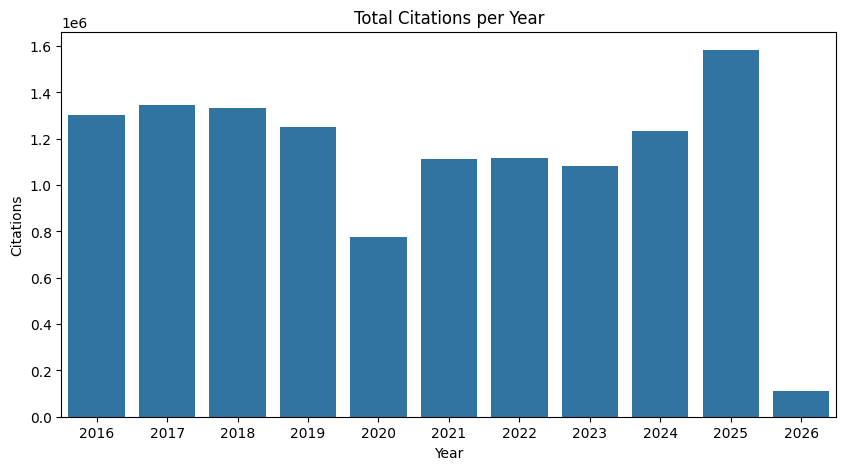

In [15]:
plt.figure(figsize=(10, 5))
sns.barplot(data = yearly,x='year',y='citations')
plt.title("Total Citations per Year")
plt.xlabel("Year")
plt.ylabel("Citations")

**Plot the percentage change per year**

/var/folders/ys/_jtkggyd0hn93xqgmvmv3yy00000gp/T/ipykernel_55362/900928366.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=yearly, x="year", y="pct_change", palette=colors)


Text(0, 0.5, '% Change')

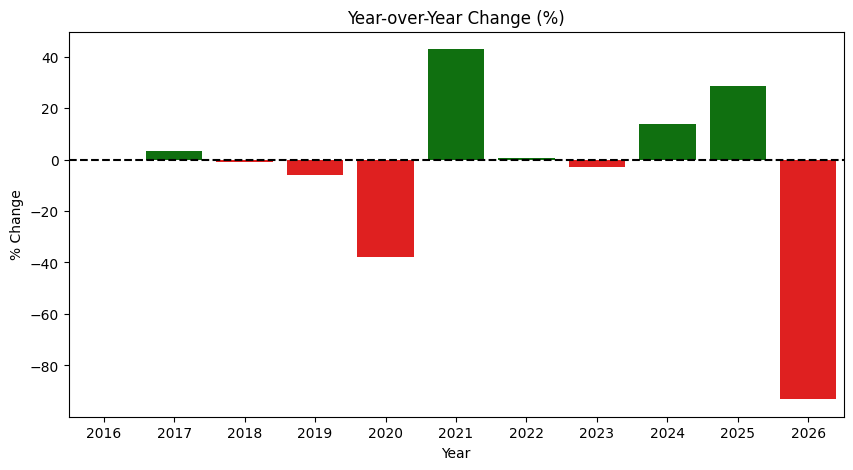

In [16]:
plt.figure(figsize=(10, 5))

colors = ["green" if x >= 0 else "red" for x in yearly["pct_change"]]

sns.barplot(data=yearly, x="year", y="pct_change", palette=colors)

plt.axhline(0, linestyle="--", color="black")

plt.title("Year-over-Year Change (%)")
plt.xlabel("Year")
plt.ylabel("% Change")

**Get citations by hour**

In [ ]:
hourly = df.groupby('hour').size().reset_index(name='citations').sort_values('hour') #citations by hour

**Plot citations by hour**

Text(0, 0.5, 'Number of Citations')

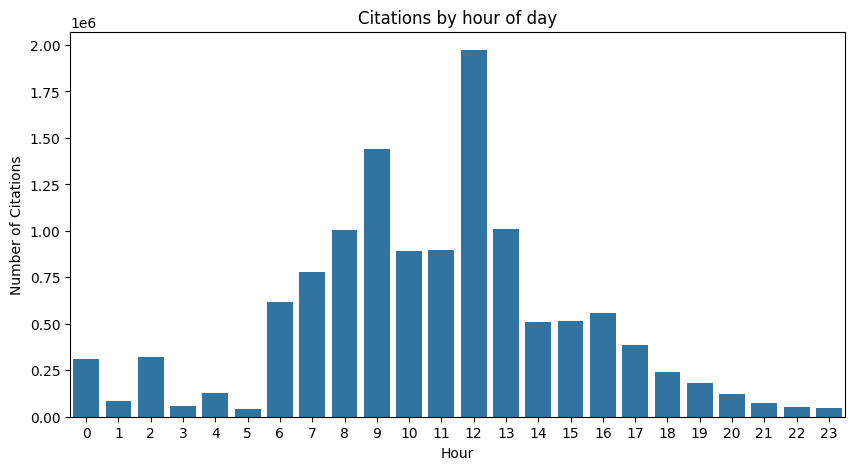

In [18]:
plt.figure(figsize=(10, 5))
sns.barplot(
    data =hourly,
    x='hour',
    y='citations'
)
plt.title("Citations by hour of day")
plt.xlabel("Hour")
plt.ylabel("Number of Citations")

**Get citations by day of week**

In [ ]:
weekly = df.groupby('day').size().reset_index(name='count')

/var/folders/ys/_jtkggyd0hn93xqgmvmv3yy00000gp/T/ipykernel_55362/905714635.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  weekly = df.groupby('day').size().reset_index(name='count')


**Plot citations by day of week**

Text(0, 0.5, 'Number of Citations')

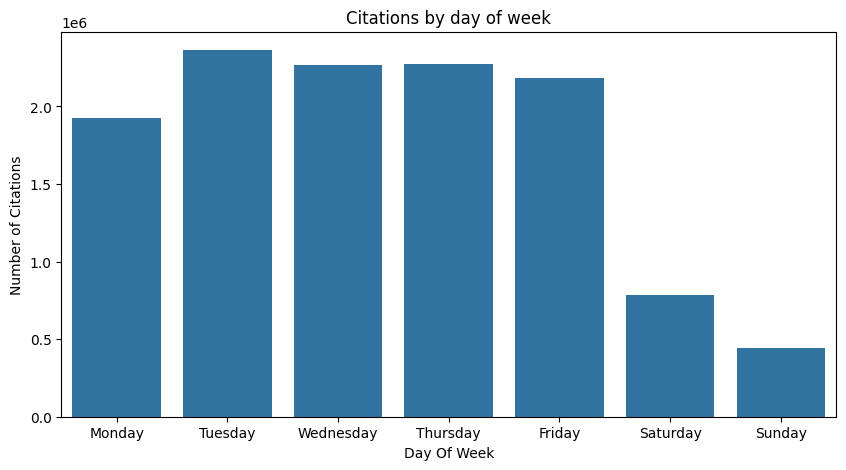

In [20]:
plt.figure(figsize=(10, 5))
sns.barplot(
    data =weekly,
    x='day',
    y='count'
)
plt.title("Citations by day of week")
plt.xlabel("Day Of Week")
plt.ylabel("Number of Citations")

**Get citations by month of year**

In [ ]:
order = ["January", "February", "March", "April", "May", "June", "July", 'August', 'September', 'October','November','December']

monthly = df.groupby('month').size().reset_index(name='count')

monthly["month"] = pd.Categorical( #order months
    monthly["month"],
    categories=order,
    ordered=True
)

monthly = monthly.sort_values("month") #sort months

**Plot citations by month of year**

Text(0, 0.5, 'Number of Citations')

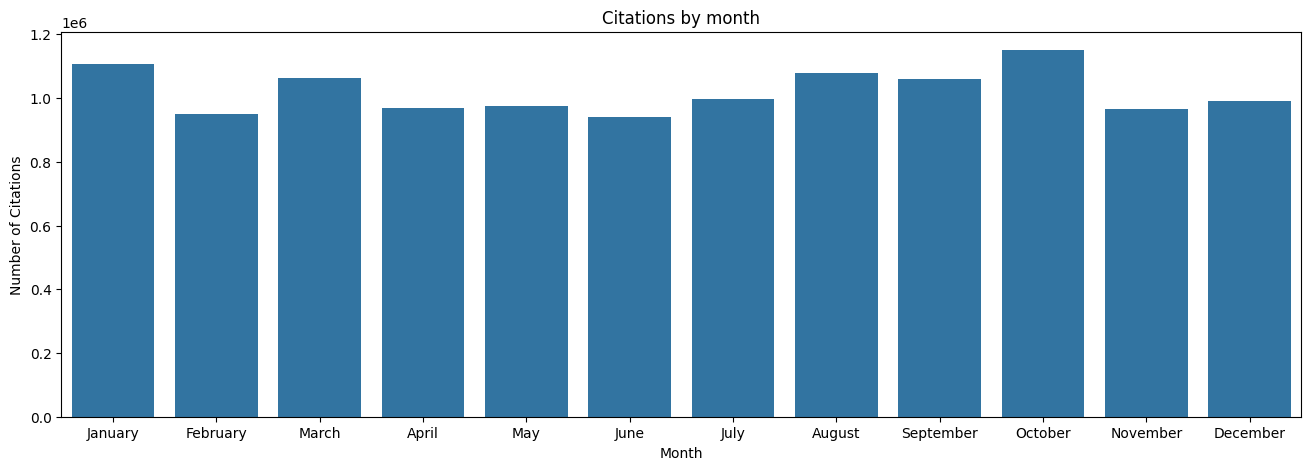

In [22]:
plt.figure(figsize=(16, 5))
sns.barplot(
    data =monthly,
    x='month',
    y='count'
)
plt.title("Citations by month")
plt.xlabel("Month")
plt.ylabel("Number of Citations")

**Make a heatmap by hour and day of week**

In [ ]:
heatmap_data = (
    df.groupby(["hour", "day"]) #make heatmap by grouping hour and day
      .size()
      .unstack(fill_value=0)
)
heatmap_data = heatmap_data.sort_index(ascending=False)

/var/folders/ys/_jtkggyd0hn93xqgmvmv3yy00000gp/T/ipykernel_55362/4047920594.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby(["hour", "day"])


**Plot heatmap**

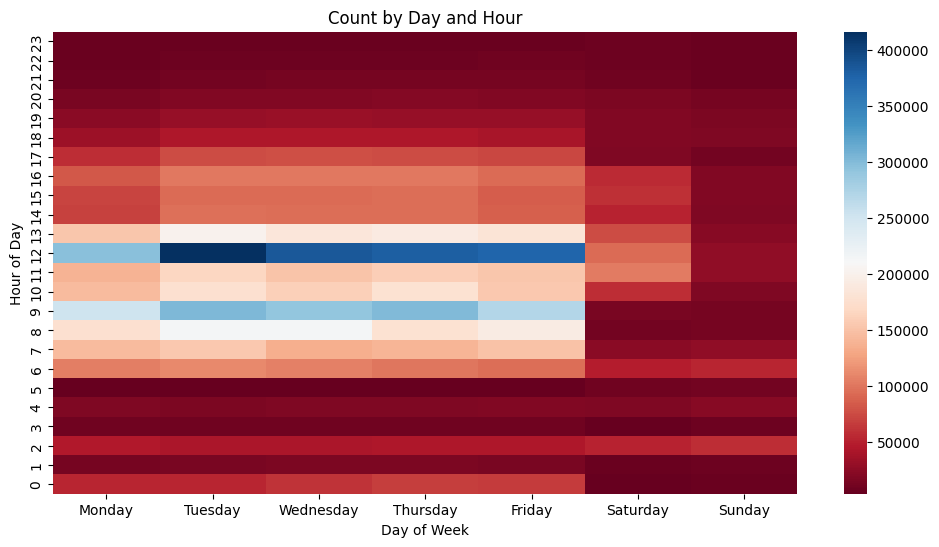

In [24]:
plt.figure(figsize=(12, 6))
sns.heatmap(heatmap_data, cmap="RdBu")

plt.xlabel("Day of Week")
plt.ylabel("Hour of Day")
plt.title("Count by Day and Hour")
plt.show()

**Get and plot the top 10 most common violations**

In [ ]:
top_violations = df['Violation Description'].value_counts().head(10).reset_index()
top_violations.columns = ["violation", "count"] #get the head of top violations

Text(0.5, 1.0, 'Top 10 Most Common Violations')

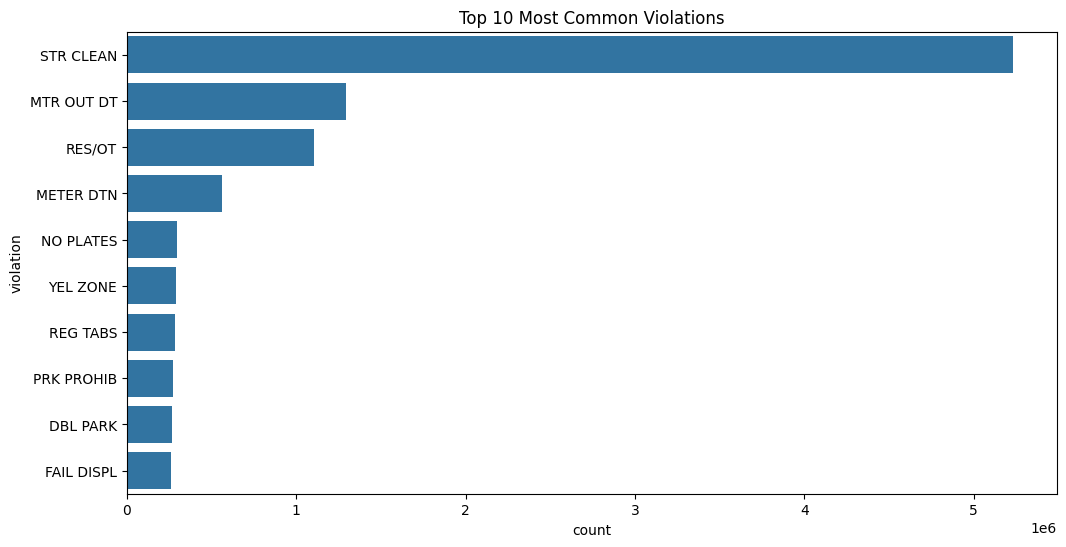

In [26]:
plt.figure(figsize=(12, 6))
sns.barplot(data=top_violations, x="count", y="violation")

plt.title("Top 10 Most Common Violations")

**Get the total fine amount by each year**

In [ ]:
yearly_fines = df.groupby('year')['Fine Amount'].sum().reset_index(name='Fine Amount')
yearly_fines #get fines by year

,year,Fine Amount
0,2016,110391713.0
1,2017,119218579.0
2,2018,120999385.0
3,2019,118408552.0
4,2020,70746406.0
5,2021,104761780.0
6,2022,107376875.0
7,2023,107532429.0
8,2024,128374224.0
9,2025,174476465.0


Text(0.5, 0, 'Year')

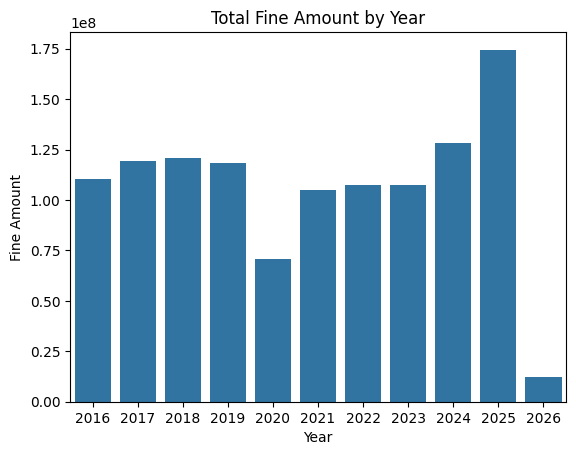

In [28]:
sns.barplot(data=yearly_fines, x="year", y="Fine Amount")

plt.title("Total Fine Amount by Year")
plt.xlabel("Year")

**Get the total amount of money collected from parking citations in 10 years**

In [72]:
df['Fine Amount'].sum()

1174558848.0

In [ ]:
df_top10 = df[df["Violation Description"].isin(top_violations['violation'])]
df_top10 #get only violations that are in the 10 most common violations


,Citation Number,Citation Issued DateTime,Violation,Violation Description,Citation Location,Vehicle Plate State,Vehicle Plate,Fine Amount,Date Added,geom,supervisor_district,analysis_neighborhood,Latitude,Longitude,year,month,hour,street
2,"""11561605T",2026-02-04 19:41:00,TRC7.2.101A,FAIL DISPL,METRO FOREST HILL STATION-DOWNTOWN,NaN,NaN,134.0,2026 Feb 09 12:00:00 AM,NaN,NaN,NaN,NaN,NaN,2026,February,19,METRO FOREST HILL STATION-DOWNTOWN
4,"""998115893",2026-02-04 19:40:00,TRC7.2.40,PRK PROHIB,101 05TH ST,AL,3A0C313,108.0,2026 Feb 09 12:00:00 AM,NaN,NaN,NaN,NaN,NaN,2026,February,19,05TH ST
5,"""11557501T",2026-02-04 19:39:00,TRC7.2.101A,FAIL DISPL,VAN NESS AVE & UNION ST,NaN,NaN,134.0,2026 Feb 09 12:00:00 AM,NaN,NaN,NaN,NaN,NaN,2026,February,19,VAN NESS AVE & UNION ST
7,"""11565492T",2026-02-04 19:32:00,TRC7.2.101A,FAIL DISPL,UNION ST & POLK ST,NaN,NaN,134.0,2026 Feb 09 12:00:00 AM,NaN,NaN,NaN,NaN,NaN,2026,February,19,UNION ST & POLK ST
9,"""11554701T",2026-02-04 19:29:00,TRC7.2.101A,FAIL DISPL,JUDAH ST & 19TH AVE,NaN,NaN,134.0,2026 Feb 09 12:00:00 AM,NaN,NaN,NaN,NaN,NaN,2026,February,19,JUDAH ST & 19TH AVE
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
12303666,PD28852762,2016-01-01 23:05:00,V22500H,DBL PARK,TWIN PEAKS,CA,58034P1,110.0,2020 Nov 19 12:00:00 AM,POINT (-122.44223999999997 37.75669000000005),8.0,Castro/Upper Market,POINT(-122.44223999999997 37.75669000000005),POINT(-122.44223999999997 37.75669000000005),2016,January,23,TWIN PEAKS
12303668,PD28547680,2016-01-01 22:50:00,V5204A,REG TABS,BAKER AND POST,CA,7HKN933,121.0,2016 Jan 01 12:00:00 AM,NaN,NaN,NaN,NaN,NaN,2016,January,22,BAKER AND POST
12303669,PD28547665,2016-01-01 22:49:00,V5204A,REG TABS,2943 BALBOA ST.,CA,5ZQH417,121.0,2020 Jul 28 12:00:00 AM,NaN,NaN,NaN,NaN,NaN,2016,January,22,BALBOA ST.
12303671,PD28547676,2016-01-01 22:45:00,V5204A,REG TABS,2540 POST ST,CA,41924P1,121.0,2016 Jan 01 12:00:00 AM,POINT (-122.44372403399996 37.78409099100003),5.0,Presidio Heights,POINT(-122.44372403399996 37.78409099100003),POINT(-122.44372403399996 37.78409099100003),2016,January,22,POST ST


**Calculate how much money the top 10 fines have collected**

In [ ]:
top10_fines = (
    df_top10.groupby("Violation Description")["Fine Amount"]
    .sum()
    .sort_values(ascending=False)
    .reset_index()
)
top10_fines #find out how much money has been raised by the top 10 violations

,Violation Description,Fine Amount
0,STR CLEAN,434963538.0
1,MTR OUT DT,108898267.0
2,RES/OT,102870103.0
3,METER DTN,51998567.0
4,REG TABS,35507579.0
5,NO PLATES,35289570.0
6,FAIL DISPL,32496477.0
7,YEL ZONE,30438515.0
8,PRK PROHIB,29610741.0
9,DBL PARK,28994122.0


In [ ]:
top10_finesMean = (
    df_top10.groupby("Violation Description")["Fine Amount"]
    .mean()
    .sort_values(ascending=False)
    .reset_index()
)
top10_finesMean #average amount raised by top 10 violations

,Violation Description,Fine Amount
0,FAIL DISPL,124.434630
1,REG TABS,123.813402
2,NO PLATES,119.954621
3,DBL PARK,109.664631
4,PRK PROHIB,107.949811
5,YEL ZONE,104.837484
6,RES/OT,93.180370
7,METER DTN,92.259837
8,MTR OUT DT,84.187475
9,STR CLEAN,83.174754


Text(0, 0.5, 'Violation')

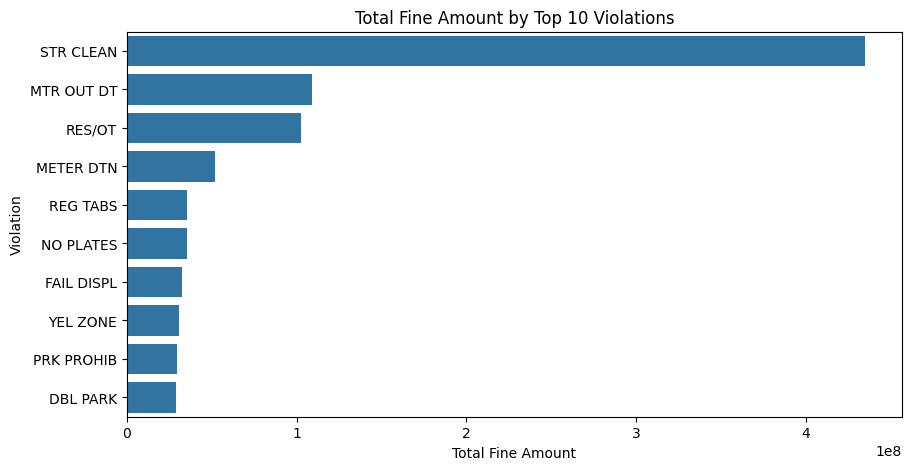

In [40]:
plt.figure(figsize=(10, 5))
sns.barplot(data=top10_fines, x="Fine Amount", y="Violation Description")

plt.title("Total Fine Amount by Top 10 Violations")
plt.xlabel("Total Fine Amount")
plt.ylabel("Violation")

**Plot and distribute the range of fine amounts**

Text(0, 0.5, 'Count')

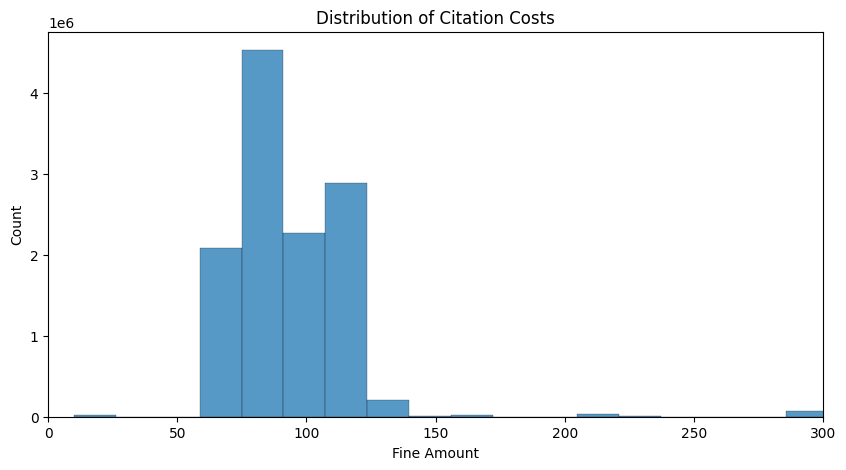

In [ ]:
plt.figure(figsize=(10, 5))

sns.histplot(df["Fine Amount"], bins=300) #plot the spread of ticket fine amounts
plt.xlim(0, 300)

plt.title("Distribution of Citation Costs")
plt.xlabel("Fine Amount")
plt.ylabel("Count")

**Average fine amount**

In [ ]:
df['Fine Amount'].mean() #get the average fine amount

95.93430042569172

**Median fine amount**

In [ ]:
df['Fine Amount'].median() #median fine amount

90.0

**Average fine amount by year**

In [ ]:
df.groupby('year')['Fine Amount'].mean() #average fine amount by year

year
2016     84.617676
2017     88.604356
2018     90.863504
2019     94.663152
2020     90.995088
2021     94.331881
2022     96.271479
2023     99.309228
2024    104.162656
2025    110.213853
2026    112.546793
Name: Fine Amount, dtype: float64

**Find the top 5 vehicle plates with the most citations**

In [ ]:
top5 = df["Vehicle Plate"].value_counts().head(5) # top five plates with most tickets

In [38]:
top5

Vehicle Plate
70358W1    1231
23801V1    1150
11932J2    1130
70509Z1    1050
70302Z1     961
Name: count, dtype: int64

**Find the top 10 streets with the most parking citations**

In [ ]:
top10_streets = (
    df["street"]
    .value_counts()
    .head(10)#top 10 streets with most tickets
    .reset_index()
)

top10_streets.columns = ["street", "count"]
top10_streets

,street,count
0,MISSION ST,327522
1,CALIFORNIA ST,118890
2,SUTTER ST,117452
3,POST ST,113689
4,FOLSOM ST,106450
5,SACRAMENTO ST,106434
6,FILLMORE ST,102769
7,BUSH ST,94090
8,HARRISON ST,93634
9,VALENCIA ST,93561


**Plot the top 10 streets**

Text(0, 0.5, 'Count')

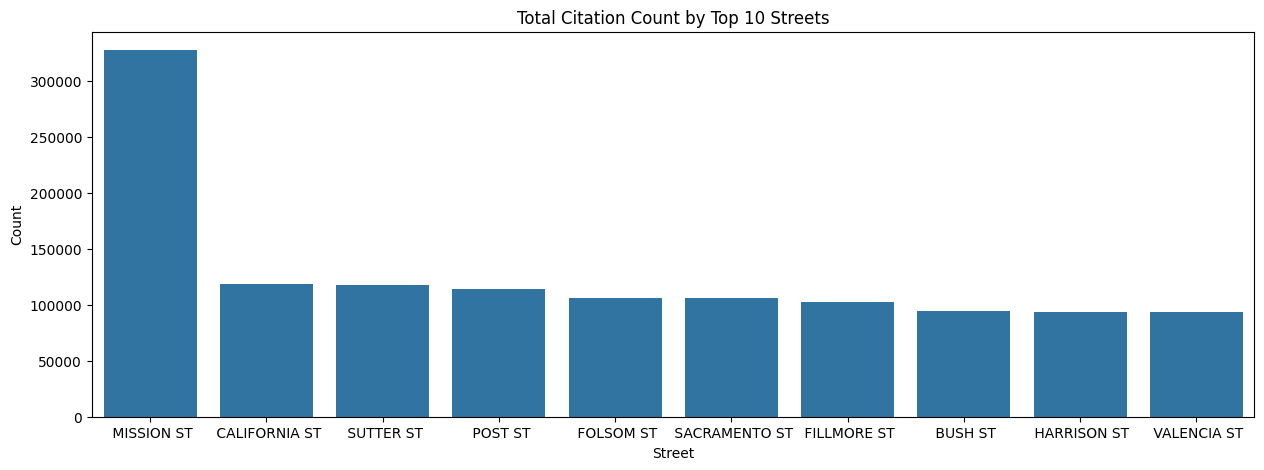

In [ ]:
plt.figure(figsize=(15, 5))
sns.barplot(data=top10_streets, x="street", y="count") #plot top 10 streets

plt.title("Total Citation Count by Top 10 Streets")
plt.xlabel("Street")
plt.ylabel("Count")

In [47]:
df.head()

,Citation Number,Citation Issued DateTime,Violation,Violation Description,Citation Location,Vehicle Plate State,Vehicle Plate,Fine Amount,Date Added,geom,supervisor_district,analysis_neighborhood,Latitude,Longitude,year,month,hour,street,day
2,"""11561605T",2026-02-04 19:41:00,TRC7.2.101A,FAIL DISPL,METRO FOREST HILL STATION-DOWNTOWN,NaN,NaN,134.0,2026 Feb 09 12:00:00 AM,NaN,NaN,NaN,NaN,NaN,2026,February,19,METRO FOREST HILL STATION-DOWNTOWN,Wednesday
4,"""998115893",2026-02-04 19:40:00,TRC7.2.40,PRK PROHIB,101 05TH ST,AL,3A0C313,108.0,2026 Feb 09 12:00:00 AM,NaN,NaN,NaN,NaN,NaN,2026,February,19,05TH ST,Wednesday
5,"""11557501T",2026-02-04 19:39:00,TRC7.2.101A,FAIL DISPL,VAN NESS AVE & UNION ST,NaN,NaN,134.0,2026 Feb 09 12:00:00 AM,NaN,NaN,NaN,NaN,NaN,2026,February,19,VAN NESS AVE & UNION ST,Wednesday
6,"""997794431",2026-02-04 19:38:00,V22500B,PK/CROSS,598 28TH AVE,CA,CD56QH,108.0,2026 Feb 09 12:00:00 AM,NaN,NaN,NaN,NaN,NaN,2026,February,19,28TH AVE,Wednesday
7,"""11565492T",2026-02-04 19:32:00,TRC7.2.101A,FAIL DISPL,UNION ST & POLK ST,NaN,NaN,134.0,2026 Feb 09 12:00:00 AM,NaN,NaN,NaN,NaN,NaN,2026,February,19,UNION ST & POLK ST,Wednesday


In [48]:
df_top = df[df["street"].isin(top10_streets['street'])].copy()
df_top

,Citation Number,Citation Issued DateTime,Violation,Violation Description,Citation Location,Vehicle Plate State,Vehicle Plate,Fine Amount,Date Added,geom,supervisor_district,analysis_neighborhood,Latitude,Longitude,year,month,hour,street,day
34,"""997350981",2026-02-04 18:20:00,TRC7.2.26,YEL ZONE,503 FOLSOM ST,TX,XCB0532,108.0,2026 Feb 09 12:00:00 AM,NaN,NaN,NaN,NaN,NaN,2026,February,18,FOLSOM ST,Wednesday
35,"""997350970",2026-02-04 18:18:00,TRC7.2.26,YEL ZONE,503 FOLSOM ST,CA,A668MO,108.0,2026 Feb 09 12:00:00 AM,NaN,NaN,NaN,NaN,NaN,2026,February,18,FOLSOM ST,Wednesday
44,"""997946180",2026-02-04 17:44:00,TRC7.2.23B,MTR OUT DT,1415 HARRISON ST,WA,BSV6957,107.0,2026 Feb 09 12:00:00 AM,NaN,NaN,NaN,NaN,NaN,2026,February,17,HARRISON ST,Wednesday
58,"""997667425",2026-02-04 16:40:00,TRC7.2.40,PRK PROHIB,470 POST ST,WI,AKC4730,108.0,2026 Feb 09 12:00:00 AM,NaN,NaN,NaN,NaN,NaN,2026,February,16,POST ST,Wednesday
99,"""997737484",2026-02-04 14:34:00,TRC7.2.83,TRK ZONE,304 POST ST,CO,DXFX55,108.0,2026 Feb 09 12:00:00 AM,NaN,NaN,NaN,NaN,NaN,2026,February,14,POST ST,Wednesday
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
12303602,863889740,2016-01-02 02:12:00,TRC7.2.22,STR CLEAN,1043 MISSION ST,CA,7KTF409,68.0,2017 May 02 12:00:00 AM,POINT (-122.41001350399995 37.77983728700008),6.0,South of Market,POINT(-122.41001350399995 37.77983728700008),POINT(-122.41001350399995 37.77983728700008),2016,January,2,MISSION ST,Saturday
12303603,863979093,2016-01-02 02:11:00,TRC7.2.22,STR CLEAN,1105 MISSION ST,CA,6EGD071,68.0,2017 May 02 12:00:00 AM,POINT (-122.41100267399997 37.779048438000075),6.0,South of Market,POINT(-122.41100267399997 37.779048438000075),POINT(-122.41100267399997 37.779048438000075),2016,January,2,MISSION ST,Saturday
12303604,863979082,2016-01-02 02:10:00,TRC7.2.22,STR CLEAN,1161 MISSION ST,CA,7MXF418,68.0,2017 May 02 12:00:00 AM,POINT (-122.41199601599999 37.777900997000074),6.0,South of Market,POINT(-122.41199601599999 37.777900997000074),POINT(-122.41199601599999 37.777900997000074),2016,January,2,MISSION ST,Saturday
12303605,863889736,2016-01-02 02:09:00,TRC7.2.22,STR CLEAN,1413 MISSION ST,CA,7KHH243,68.0,2017 May 02 12:00:00 AM,POINT (-122.41600896199998 37.775117256000044),6.0,South of Market,POINT(-122.41600896199998 37.775117256000044),POINT(-122.41600896199998 37.775117256000044),2016,January,2,MISSION ST,Saturday


**Make a heatmap by the top 10 streets and hour of day**

In [ ]:
streetheatmap_data = (
    df_top.groupby(["street", "hour"])
          .size()#make a heatmap of streets and hours
          .unstack(fill_value=0)
)

In [54]:
streetheatmap_data

hour,0,1,2,3,4,5,6,7,8,9,...,14,15,16,17,18,19,20,21,22,23
street,,,,,,,,,,,,,,,,,,,,,
BUSH ST,15,53,2138,4,8,8,8263,14905,3274,8808,...,3533,3687,5279,4579,1216,479,204,133,113,126
CALIFORNIA ST,27,60,2917,36,91,127,4206,14224,6902,14621,...,5756,7961,6917,4504,1039,606,369,205,218,232
FILLMORE ST,56,28,4,28,39,60,15870,416,10673,14621,...,5083,4860,5402,3775,1037,924,568,242,172,164
FOLSOM ST,16859,185,45,68,9407,119,273,1397,1636,15737,...,3998,3924,4160,3401,2012,1345,864,350,416,536
HARRISON ST,13455,1020,1375,274,5311,33,737,1240,10268,6758,...,3159,3774,4490,4182,1767,1180,568,198,377,723
MISSION ST,1947,385,48008,854,21260,23289,11132,6950,7110,9161,...,19019,19799,26233,15638,7704,3810,1306,611,311,206
POST ST,42,22,1837,47,53,46,25419,4945,2874,8393,...,5825,5079,7668,5455,595,327,232,159,138,133
SACRAMENTO ST,13,27,1265,51,21,38,5071,10019,2654,13415,...,5473,11047,8037,3879,605,587,401,176,185,207
SUTTER ST,40,35,3146,124,20,22,2165,13469,4795,14015,...,4768,3800,16549,6150,765,525,363,215,204,282


Text(145.72222222222223, 0.5, 'Street')

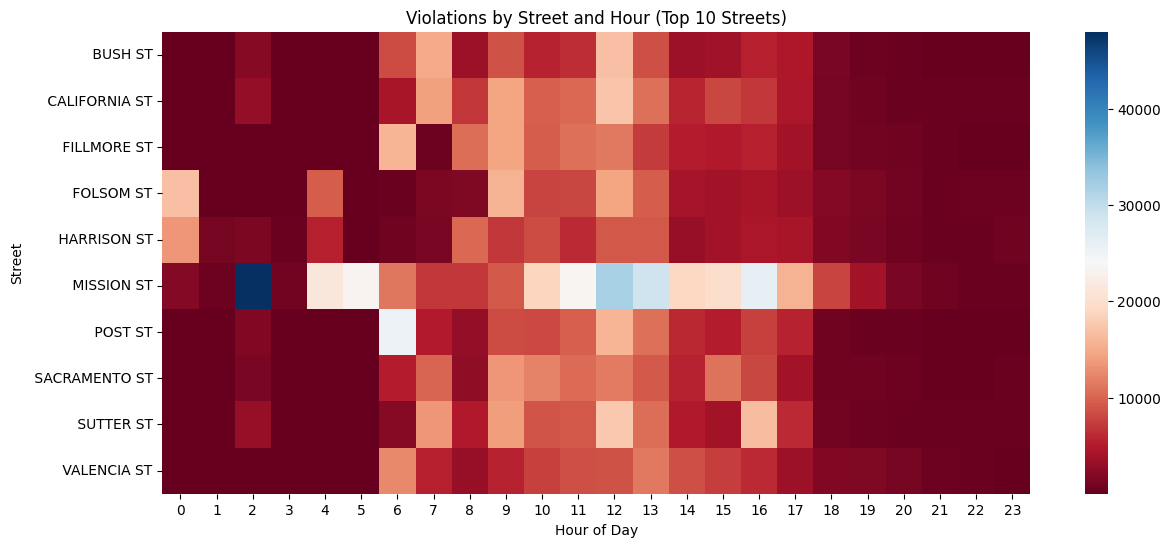

In [ ]:
plt.figure(figsize=(14, 6))

sns.heatmap(streetheatmap_data, cmap="RdBu")#plot heatmap

plt.title("Violations by Street and Hour (Top 10 Streets)")
plt.xlabel("Hour of Day")
plt.ylabel("Street")

**Get the stats of the top 10 streets including total count, average fine, total fine amount**

In [ ]:
street_stats = (
    df_top.groupby('street')
    .agg(
        ticket_count=('Citation Number','count'),
        avg_fine=('Fine Amount','mean'),
        total_fine=('Fine Amount','sum')
    )
    .sort_values('ticket_count', ascending=False)
)
street_stats #grooup by streets and get street stats

,ticket_count,avg_fine,total_fine
street,,,
MISSION ST,327522,103.950938,34046219.0
CALIFORNIA ST,118890,93.830869,11155552.0
SUTTER ST,117452,103.170904,12117629.0
POST ST,113689,97.492651,11083842.0
FOLSOM ST,106450,97.151677,10341796.0
SACRAMENTO ST,106434,93.366791,9937401.0
FILLMORE ST,102769,92.953858,9552775.0
BUSH ST,94090,95.827410,9016401.0
HARRISON ST,93634,93.817524,8784510.0


In [58]:
df.columns

Index(['Citation Number', 'Citation Issued DateTime', 'Violation',
       'Violation Description', 'Citation Location', 'Vehicle Plate State',
       'Vehicle Plate', 'Fine Amount', 'Date Added', 'geom',
       'supervisor_district', 'analysis_neighborhood', 'Latitude', 'Longitude',
       'year', 'month', 'hour', 'street', 'day'],
      dtype='object')

In [61]:
sample = df["Fine Amount"].sample(10000, random_state=0)

**Plot a sample of the distribution of fine amounts**

Text(0.5, 0, 'Fine Amount')

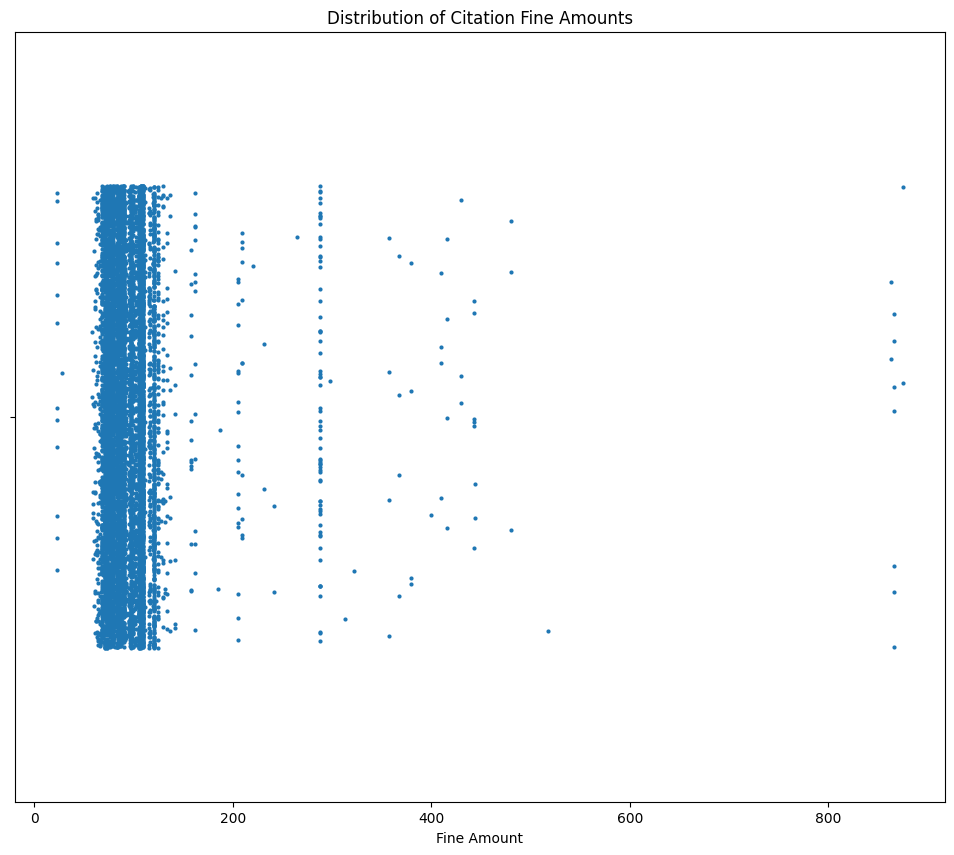

In [63]:
plt.figure(figsize=(12, 10))

sns.stripplot(x=sample, jitter=0.3, size=3)

plt.title("Distribution of Citation Fine Amounts")
plt.xlabel("Fine Amount")

**The most expensive violations**

In [67]:
df.groupby('Violation Description')['Fine Amount'].mean().sort_values(ascending= False).head(10)

Violation Description
OB TRF N P    1001.310345
FRD DIS PL     873.200000
ON STREET      870.620576
ILG PRK BL     870.153846
OFF STREET     868.054608
ON ST LST      867.005081
PL NT PERS     866.625000
MISUSE DP      866.000000
OFF ST LST     863.668666
OBSTR PRMT     688.400000
Name: Fine Amount, dtype: float64

**The least expensive violations**

In [68]:
df.groupby('Violation Description')['Fine Amount'].mean().sort_values(ascending= False).tail(10)

Violation Description
ILL PKG       23.081737
COMM VEH      23.000000
FIRETRAIL     23.000000
RD/WH ZONE    23.000000
NO STOP BP    23.000000
ALM TME 15    23.000000
SGTSEE BUS    23.000000
PRK ON RGT    23.000000
18 " CURB"    23.000000
RESTR PRK     23.000000
Name: Fine Amount, dtype: float64

**Get a sample of 100,000 longitude and latitude points**

In [ ]:
df_sample = df[["Latitude", "Longitude"]].dropna().sample(100000, random_state=0) #get random sample of 100000 poitns with longitude and latitude
coords = df_sample["Latitude"].str.extract(r"POINT\(([-\d\.]+) ([-\d\.]+)\)") #extract them to be in correct format
df_sample["Longitude"] = coords[0].astype(float) #convert to float
df_sample["Latitude"] = coords[1].astype(float)


**Only include the points that are greater than 5 so map is not overpopulated**

In [ ]:
loc_counts = (
    df_sample.groupby(["Latitude", "Longitude"])
    .size()
    .reset_index(name="count")
)

loc_counts = loc_counts[loc_counts["count"] > 5] #only keep points with more than 5 instances

In [120]:
loc_counts

,Latitude,Longitude,count
17,37.573934,-122.339558,30
19,37.573956,-122.339527,14
20,37.573967,-122.339511,7
23,37.573988,-122.339480,10
24,37.573999,-122.339465,6
...,...,...,...
60019,38.248570,-122.036436,8
60024,38.248718,-122.035887,9
60027,38.248870,-122.035897,7
60030,38.249097,-122.035851,6


**Map the points onto a map of sanfrancisco**

In [ ]:
m = folium.Map(location=[37.77, -122.42], zoom_start=12) #get a map of SF
heat_data = loc_counts[["Latitude", "Longitude"]].values.tolist() #get values in a list
HeatMap(heat_data, radius=10).add_to(m)#plot over map of sf
m.save("sf_heatmap.html")#save to html file to see in browser


In [98]:
df_sample.groupby(["Latitude", "Longitude"]).size().describe()

count    60126.000000
mean         1.663174
std          5.214652
min          1.000000
25%          1.000000
50%          1.000000
75%          2.000000
max       1075.000000
dtype: float64